### B.5. Implement the spectral clustering algorithm and test its performance on the spiral dataset. Compare  these  clustering  results  with  those  obtained  by  the  simple  K-means  clustering algorithm. ###

# Spectral Clustering

Spectral clustering is a **graph-based clustering method** that uses linear algebra (eigenvalues and eigenvectors) to identify structure in data, especially when clusters are **non-convex** or not well separated in Euclidean space.

---

## 1. Intuition (Big Picture)

Instead of asking:

> *Which points are close in Euclidean space?*

Spectral clustering asks:

> **If we build a graph where similar points are strongly connected, how can we partition this graph into well-connected groups?**

Key idea:
- Data points are treated as **nodes**
- Similarity between points becomes an **edge weight**
- Good clusters have **strong internal connections** and **weak external connections**

This transforms clustering into a **graph partitioning problem**.

## Full Algorithm (Normalized Spectral Clustering)

1. Compute the similarity matrix $W$
2. Compute the degree matrix $D$
3. Compute the normalized Laplacian  
$$
L_{\text{sym}} = I - D^{-1/2} W D^{-1/2}
$$
4. Compute the first $k$ eigenvectors of $L_{\text{sym}}$
5. Normalize each row of the eigenvector matrix
6. Apply k-means to the rows
7. Output cluster labels

## Why Spectral Clustering Works

Spectral clustering approximately minimizes graph partitioning objectives such as:
- **Ratio Cut**
- **Normalized Cut**

The eigenvectors of the graph Laplacian reveal the natural low-dimensional structure of the data, making clusters more separable.

---

## Geometric Interpretation

Spectral clustering is effective when data lies on a **non-linear manifold**.

For example:
- k-means fails on the *two-moons* dataset
- Spectral clustering succeeds by using graph connectivity instead of raw distance

---

## When to Use Spectral Clustering

**Advantages**
- Handles non-convex clusters
- Works well on graph and network data
- Effective for image segmentation and community detection

**Limitations**
- Computationally expensive for large datasets
- Requires careful construction of the similarity graph
- Number of clusters $k$ must be specified in advance


In [4]:
# Standard libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Plotting libraries
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm

# scikit-learn
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

> ### Data Preparation 

In [5]:
random_seed = 42
plt.style.use('dark_background')

X, y = make_blobs(n_samples=200, n_features=2, centers=1, cluster_std=0.15, random_state=random_seed)
# center at the origin
X = X - np.mean(X, axis=0)

X1, y1 = make_circles(n_samples=(600, 200), noise=0.04, factor=0.5, random_state=random_seed)
# add 1 to (make_circles) labels to account for (make_blobs) label
y1 = y1 + 1
# increase the radius
X1 = X1*3

X = np.concatenate((X, X1), axis=0)
y = np.concatenate((y, y1), axis=0)

In [6]:
plot_colors = cm.tab10.colors
y_colors = np.array(plot_colors)[y]

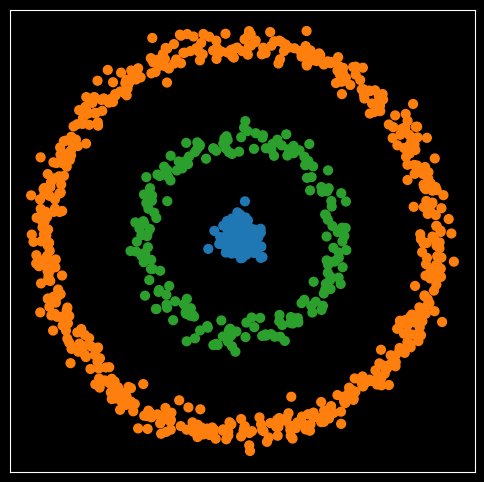

In [7]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], marker='o', s=40, color=y_colors)

ax.tick_params(axis='both',which='both',bottom=False,top=False,left=False,right=False,
            labelbottom=False,labeltop=False,labelleft=False,labelright=False);
ax.set(xlabel=None, ylabel=None)
plt.show()
# plt.axis('off')
# plt.savefig('plot.png', bbox_inches='tight', dpi=600, transparent=True)

---

## 2. Step 1: Build a Similarity Graph

Given data points  
$$
x_1, x_2, \dots, x_n
$$

we construct a weighted graph.

### Common similarity functions

**Gaussian (RBF) kernel**:
$$
W_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)
$$

Other options:
- $k$-nearest neighbors graph
- $\varepsilon$-neighborhood graph
- Cosine similarity (for text data)

This produces a **similarity (weight) matrix**:
$$
W \in \mathbb{R}^{n \times n}
$$


In [ ]:
sigma = 1
A = -1 * np.square(X[:, None, :] - X[None, :, :]).sum(axis=-1)
A = np.exp(A / (2* sigma**2))
np.fill_diagonal(A, 0)

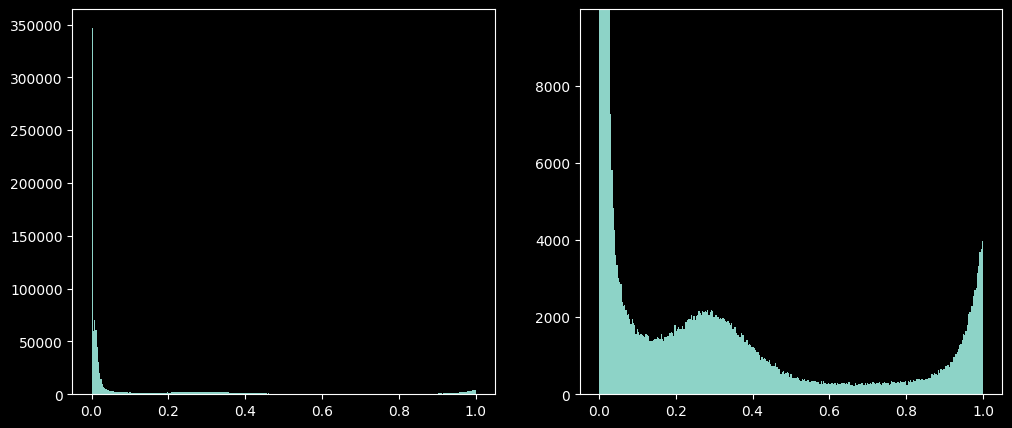

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bin_values, _, _ = ax1.hist(A.flatten(), bins='auto')

# limit the y-axis to the value of the 10th bin
ax2.hist(A.flatten(), bins='auto')
ax2.set_ylim([0, bin_values[8]])

plt.show()

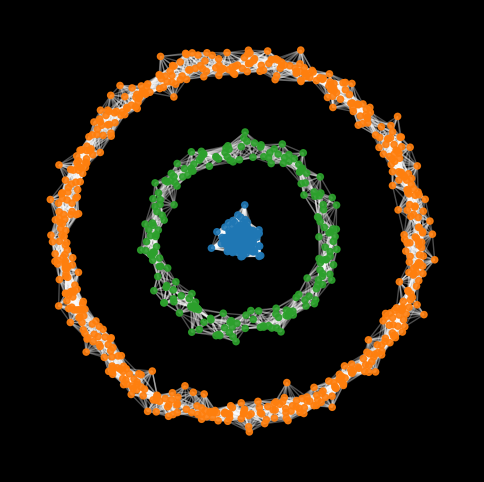

In [10]:
A1 = np.copy(A)
A1[A1 < 0.9] = 0
G = nx.from_numpy_array(A1)

plt.figure(figsize=(6,6))
plt.axis('off')
nx.draw_networkx_nodes(G, pos=X, node_size=20, node_color=y_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos=X, edge_color="white", alpha=0.3)
plt.show()

## 3. Step 2: Graph Laplacian

### Degree matrix

$$
D_{ii} = \sum_{j=1}^{n} W_{ij}
$$

### Types of graph Laplacians

1. **Unnormalized Laplacian**
$$
L = D - W
$$

2. **Normalized (symmetric) Laplacian**
$$
L_{\text{sym}} = I - D^{-1/2} W D^{-1/2}
$$

3. **Random-walk Laplacian**
$$
L_{\text{rw}} = I - D^{-1} W
$$

The graph Laplacian encodes the connectivity structure of the graph.


For this we are Using $\textbf{Normalized (symmetric) Laplacian}$

In [20]:
# identity matrix
I = np.zeros_like(A)
np.fill_diagonal(I, 1)

# degree matrix
D = np.zeros_like(A)
np.fill_diagonal(D, np.sum(A,axis=1))
D_inv_sqrt = np.linalg.inv(np.sqrt(D))

L = I - np.dot(D_inv_sqrt, A).dot(D_inv_sqrt)

## 4. Step 3: Eigenvector Embedding

We solve the eigenvalue problem:
$$
L_{\text{sym}} v = \lambda v
$$

Let  
$$
v_1, v_2, \dots, v_k
$$

be the eigenvectors corresponding to the **smallest $k$ eigenvalues**.

Construct the matrix:
$$
U =
\begin{bmatrix}
v_1 & v_2 & \cdots & v_k
\end{bmatrix}
\in \mathbb{R}^{n \times k}
$$

Each row of $U$ represents a new embedding of a data point.

In [12]:
eigenvalues, eigenvectors = np.linalg.eig(L)
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real

# Order the eigenvalues in an increasing order
ind = np.argsort(eigenvalues, axis=0)
eigenvalues_sorted = np.take_along_axis(eigenvalues, ind, axis=0)

# Order the eigenvectors based on the magnitude of their corresponding eigenvalues
eigenvectors_sorted = eigenvectors.take(ind, axis=1)

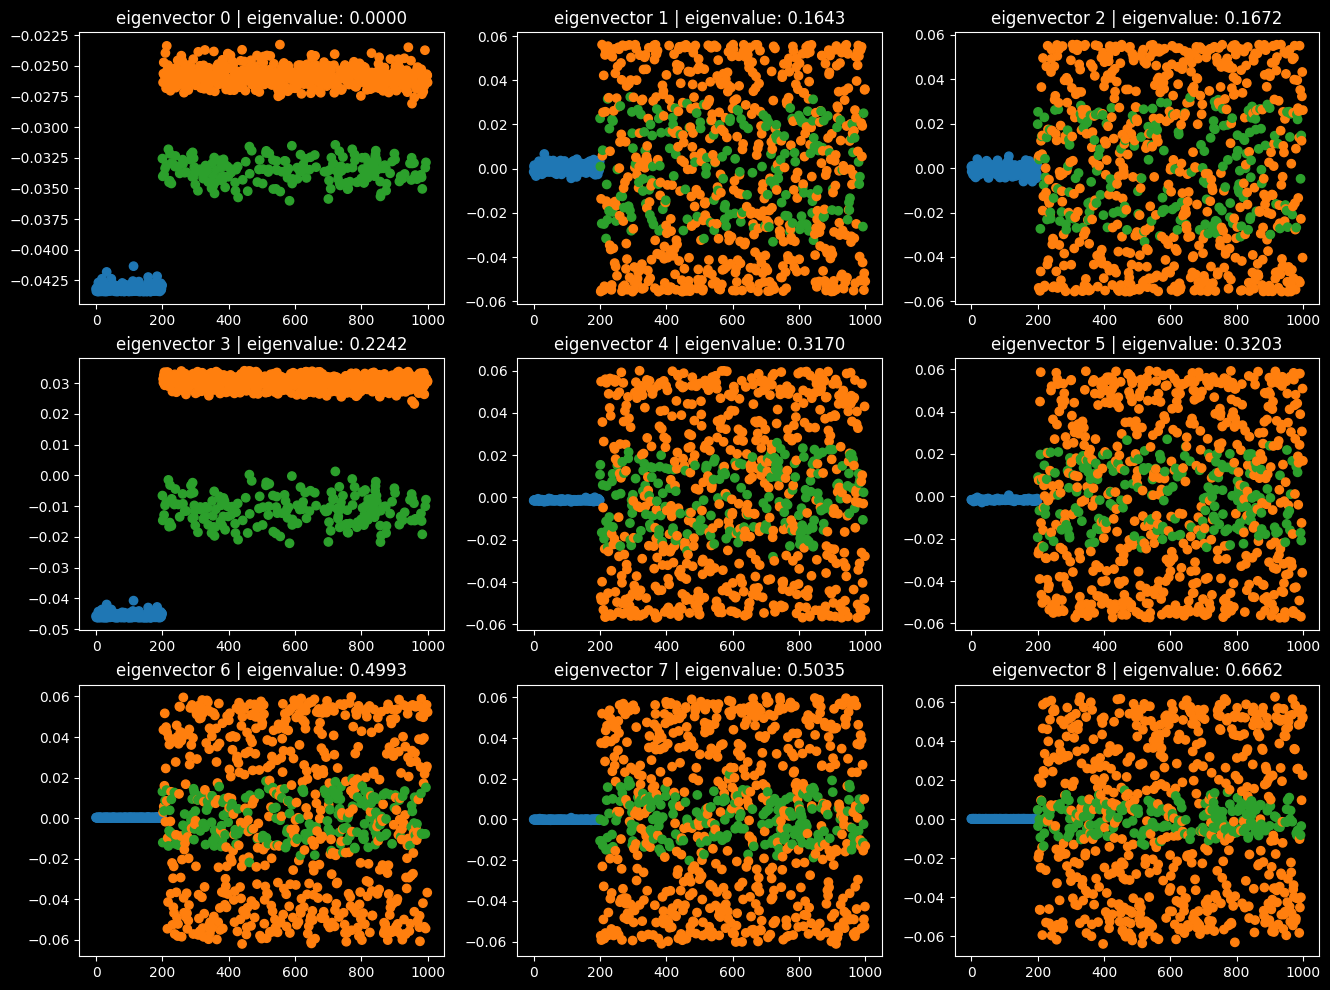

In [13]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
eigen_v_x = np.linspace(0, eigenvectors_sorted.shape[0], eigenvectors_sorted.shape[0])

for j, ax in enumerate(fig.axes):
  eigen_v_y = eigenvectors_sorted[:,j]
  ax.scatter(eigen_v_x, eigen_v_y, marker='o', color=y_colors)
  ax.set_title(f'eigenvector {j} | eigenvalue: {eigenvalues_sorted[j]:.4f}')

plt.show()


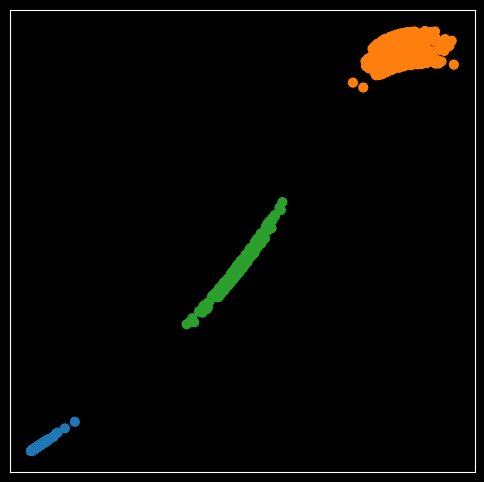

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(eigenvectors_sorted[:,0], eigenvectors_sorted[:,3], marker='o', s=40, color=y_colors)

ax.tick_params(axis='both',which='both',bottom=False,top=False,left=False,right=False,
            labelbottom=False,labeltop=False,labelleft=False,labelright=False);
ax.set(xlabel=None, ylabel=None)
plt.show()

## 5. Step 4: Clustering in Eigenvector Space

Treat each row of $U$ as a point in:
$$
\mathbb{R}^k
$$

and apply **k-means clustering**.

The resulting labels are the final cluster assignments.

In [29]:
X_transformed = eigenvectors_sorted[:,[0,3]]

scaler = StandardScaler()
scaler.fit(X_transformed)
X_transformed_scaled = scaler.transform(X_transformed)


kmeans = KMeans(n_clusters = 3, random_state = random_seed, n_init='auto')
kmeans.fit(X_transformed_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


> ### Data Plotting and Comparison with Actual cluster  

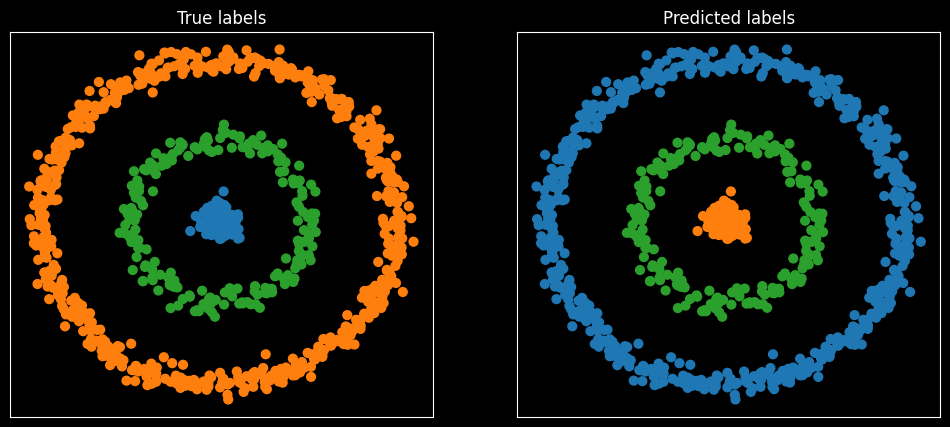

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X[:,0], X[:,1], marker='o', s=40, color=y_colors)
ax1.tick_params(axis='both',which='both',bottom=False,top=False,left=False,right=False,
            labelbottom=False,labeltop=False,labelleft=False,labelright=False);
ax1.set(xlabel=None, ylabel=None)
ax1.set_title('True labels')

ax2.scatter(X[:,0], X[:,1], marker='o', s=40, color=np.array(plot_colors)[kmeans.labels_])
ax2.tick_params(axis='both',which='both',bottom=False,top=False,left=False,right=False,
            labelbottom=False,labeltop=False,labelleft=False,labelright=False);
ax2.set(xlabel=None, ylabel=None)
ax2.set_title('Predicted labels')

plt.show()

> ### Comparison with Simple K-Means Clustering  

In [31]:
kmeans_raw = KMeans(n_clusters=3, random_state=random_seed, n_init='auto')
kmeans_raw.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


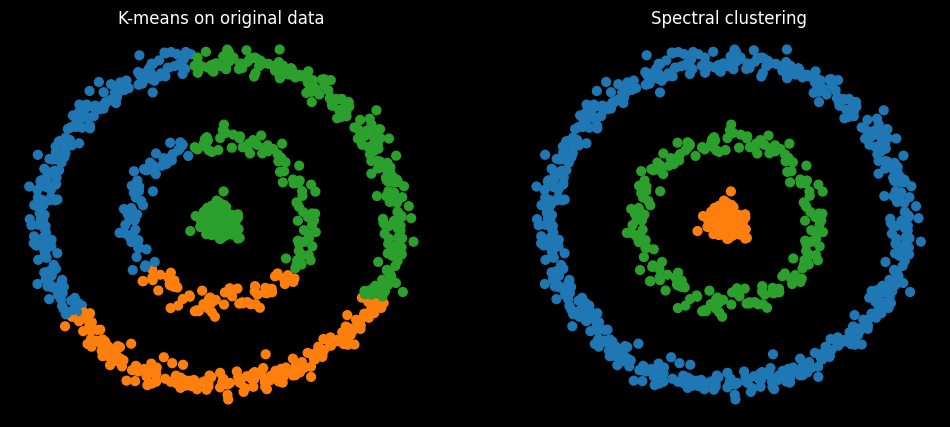

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.scatter(X[:,0], X[:,1], s=40, 
            color=np.array(plot_colors)[kmeans_raw.labels_])
ax1.set_title("K-means on original data")
ax1.axis('off')

ax2.scatter(X[:,0], X[:,1], s=40, 
            color=np.array(plot_colors)[kmeans.labels_])
ax2.set_title("Spectral clustering")
ax2.axis('off')

plt.show()


## Conclusion

K-means clustering fails to correctly separate the non-linear structure of the data, as it assumes convex clusters. Spectral clustering, by leveraging graph connectivity and Laplacian eigenvectors, successfully separates the data according to its intrinsic geometry.
